# RetailHero — user-item ranking with causal uplift

A ranking pipeline over (client, product) pairs on the X5 RetailHero dataset.
The treatment is the SMS campaign flag `treatment_flg`, randomized at the
client level; the outcome on the user-item side is whether the client bought
the product in the held-out outcome window.

The notebook covers:

- §1 — data loading and quality checks
- §2 — temporal split into history and outcome windows
- §3 — client-level uplift baseline (S / T / DR learners, AIPW)
- §4 — user-item ranking: candidate generation, relevance, uplift, mixed ranking
- §5 — budget sensitivity at varying K
- §6 — limitations

Treatment is client-level: there is no per-item recommendation flag in the
data, so `tau(u, i)` is read as the heterogeneous response of client `u` to
the campaign on product `i`. The notebook enforces this with an assertion on
the joined table.


## 1. Setup and data loading

Cached parquet artifacts from earlier runs are reused when available. The
first build step converts the 4.5 GB `purchases.csv` to ~0.5 GB zstd parquet
via DuckDB; everything downstream reads parquet.


In [1]:
import json, time, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from catboost import CatBoostClassifier, CatBoostRegressor
import duckdb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 120,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.20

MAX_USER_HISTORY_PRODUCTS = 50
N_GLOBAL_POPULAR = 200
MAX_CANDIDATES_PER_USER = 250

KS = [1, 3, 5, 10, 20]
LAMBDA_GRID = [-5, -2, -1, -0.5, 0, 0.25, 0.5, 1, 2, 5, 10]
PROPENSITY_CLIP = 0.05
N_BOOT = 300

# None = use all ~200k labelled clients; the default keeps peak RAM under 8 GB.
DEBUG_SAMPLE_CLIENTS = 20000

CB_ITERS = 250
CB_LR = 0.05
CB_DEPTH = 6
CB_ES = 30

DATA_DIR = Path("retailhero-uplift/data")
OUT_DIR = Path("out_retailhero_itemized")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)
(OUT_DIR / "cache").mkdir(exist_ok=True)

PURCH_CSV = DATA_DIR / "purchases.csv"
PURCH_PARQUET = DATA_DIR / "purchases.parquet"
CLIENT_FEAT_PQ = DATA_DIR / "client_features.parquet"


def cb_clf(**kw):
    params = dict(
        iterations=CB_ITERS, learning_rate=CB_LR, depth=CB_DEPTH,
        loss_function="Logloss", eval_metric="AUC",
        verbose=False, allow_writing_files=False,
        random_seed=RANDOM_STATE, early_stopping_rounds=CB_ES,
    )
    params.update(kw)
    return CatBoostClassifier(**params)


def cb_reg(**kw):
    params = dict(
        iterations=CB_ITERS, learning_rate=CB_LR, depth=CB_DEPTH,
        loss_function="RMSE",
        verbose=False, allow_writing_files=False,
        random_seed=RANDOM_STATE, early_stopping_rounds=CB_ES,
    )
    params.update(kw)
    return CatBoostRegressor(**params)


def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / f"{name}.png", dpi=120, bbox_inches="tight")
    plt.show()


### 1.1 Cache purchases as parquet

In [2]:
def build_purchases_parquet():
    if PURCH_PARQUET.exists():
        return f"cache hit: {PURCH_PARQUET.name} ({PURCH_PARQUET.stat().st_size/1e6:.0f} MB)"
    t0 = time.time()
    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='4GB'")
    con.execute("PRAGMA threads=4")
    con.execute(f"""
    COPY (
      SELECT CAST(client_id           AS VARCHAR)   AS client_id,
             CAST(transaction_id      AS VARCHAR)   AS transaction_id,
             CAST(transaction_datetime AS TIMESTAMP) AS transaction_datetime,
             CAST(regular_points_received AS FLOAT) AS regular_points_received,
             CAST(express_points_received AS FLOAT) AS express_points_received,
             CAST(regular_points_spent    AS FLOAT) AS regular_points_spent,
             CAST(express_points_spent    AS FLOAT) AS express_points_spent,
             CAST(purchase_sum            AS FLOAT) AS purchase_sum,
             CAST(store_id   AS VARCHAR)            AS store_id,
             CAST(product_id AS VARCHAR)            AS product_id,
             CAST(product_quantity   AS FLOAT)      AS product_quantity,
             CAST(trn_sum_from_iss   AS FLOAT)      AS trn_sum_from_iss,
             CAST(trn_sum_from_red   AS FLOAT)      AS trn_sum_from_red
      FROM read_csv_auto('{PURCH_CSV.as_posix()}', header=true)
    ) TO '{PURCH_PARQUET.as_posix()}' (FORMAT 'parquet', COMPRESSION 'zstd');
    """)
    return f"built in {time.time()-t0:.1f}s ({PURCH_PARQUET.stat().st_size/1e6:.0f} MB)"


display(Markdown(f"- `purchases.parquet`: **{build_purchases_parquet()}**"))


- `purchases.parquet`: **cache hit: purchases.parquet (489 MB)**

### 1.2 Load labelled clients and product metadata

In [3]:
df_clients_raw = pd.read_csv(DATA_DIR / "clients.csv")
df_uplift_train = pd.read_csv(DATA_DIR / "uplift_train.csv")
df_products = pd.read_csv(DATA_DIR / "products.csv")

con = duckdb.connect()
date_range = con.execute(f"""
    SELECT MIN(transaction_datetime) AS min_ts,
           MAX(transaction_datetime) AS max_ts,
           COUNT(*)                  AS n_rows,
           COUNT(DISTINCT client_id) AS n_clients,
           COUNT(DISTINCT product_id) AS n_products,
           COUNT(DISTINCT transaction_id) AS n_transactions
    FROM read_parquet('{PURCH_PARQUET.as_posix()}')
""").fetchdf().iloc[0]

summary = pd.DataFrame({"value": [
    str(date_range["min_ts"]),
    str(date_range["max_ts"]),
    f"{int(date_range['n_rows']):,}",
    f"{int(date_range['n_clients']):,}",
    f"{int(date_range['n_products']):,}",
    f"{int(date_range['n_transactions']):,}",
    f"{len(df_uplift_train):,}",
    f"{df_uplift_train['treatment_flg'].mean()*100:.2f}%",
    f"{df_uplift_train['target'].mean()*100:.2f}%",
    f"{len(df_products):,}",
    f"{len(df_clients_raw):,}",
]}, index=[
    "earliest purchase",
    "latest purchase",
    "total purchase rows",
    "unique clients with any purchase",
    "unique products in purchases.csv",
    "unique transaction_id values",
    "labelled clients in uplift_train.csv",
    "treatment share (clients)",
    "outcome share (clients)",
    "rows in products.csv",
    "rows in clients.csv",
])
display(summary)


,value
earliest purchase,2018-11-21 21:02:33
latest purchase,2019-03-18 23:40:03
total purchase rows,"45,786,568"
unique clients with any purchase,"400,162"
unique products in purchases.csv,"42,530"
unique transaction_id values,"8,045,201"
labelled clients in uplift_train.csv,"200,039"
treatment share (clients),49.98%
outcome share (clients),61.99%
rows in products.csv,"43,038"


### 1.3 Data-quality checks

Five quick assertions on the joinable keys and the binary labels.


In [4]:
checks = [
    ("client_id unique in uplift_train.csv",
     df_uplift_train["client_id"].is_unique),
    ("treatment_flg in {0, 1}",
     set(df_uplift_train["treatment_flg"].unique()).issubset({0, 1})),
    ("target in {0, 1}",
     set(df_uplift_train["target"].unique()).issubset({0, 1})),
    ("labelled clients exist in clients.csv",
     df_uplift_train["client_id"].isin(df_clients_raw["client_id"]).all()),
    ("products.csv has unique product_id",
     df_products["product_id"].is_unique),
]

dup_triples = con.execute(f"""
    SELECT COUNT(*) FROM (
        SELECT client_id, transaction_id, product_id, COUNT(*) c
        FROM read_parquet('{PURCH_PARQUET.as_posix()}')
        GROUP BY client_id, transaction_id, product_id
        HAVING c > 1)
""").fetchone()[0]
checks.append(("no duplicate (client_id, transaction_id, product_id) triples",
               dup_triples == 0))

display(pd.DataFrame(checks, columns=["check", "passes"]))
assert all(p for _, p in checks)


,check,passes
0,client_id unique in uplift_train.csv,True
1,"treatment_flg in {0, 1}",True
2,"target in {0, 1}",True
3,labelled clients exist in clients.csv,True
4,products.csv has unique product_id,True
5,"no duplicate (client_id, transaction_id, produ...",True


## 2. Temporal split

The purchase log ends before the SMS campaign is delivered. For the item-side
labels we still need a temporal split: the earliest 70% of dates feed the
history features, the latest 30% supply the (client, product) outcome
indicator `y_ui`.

Note that both windows sit *before* the campaign, so the randomized
`treatment_flg` cannot causally drive `y_ui` — the per-item uplift in §4 is
correlational by construction. The pipeline (§4.5–4.7) is still meaningful as
a machinery check; the headline causal numbers come from the client-level
analysis in §3, whose outcome `target` is the post-campaign purchase flag.


In [5]:
HISTORY_FRAC = 0.70

cutoff_raw = con.execute(f"""
    SELECT quantile_cont(transaction_datetime, {HISTORY_FRAC}) AS cutoff
    FROM read_parquet('{PURCH_PARQUET.as_posix()}')
""").fetchone()[0]
HIST_CUTOFF = pd.Timestamp(cutoff_raw).floor("D")

window_stats = con.execute(f"""
    SELECT
      MIN(transaction_datetime) AS earliest,
      MAX(transaction_datetime) AS latest,
      SUM(CASE WHEN transaction_datetime <  TIMESTAMP '{HIST_CUTOFF}' THEN 1 ELSE 0 END) AS n_hist_rows,
      SUM(CASE WHEN transaction_datetime >= TIMESTAMP '{HIST_CUTOFF}' THEN 1 ELSE 0 END) AS n_outc_rows,
      COUNT(DISTINCT CASE WHEN transaction_datetime <  TIMESTAMP '{HIST_CUTOFF}' THEN client_id END) AS n_hist_clients,
      COUNT(DISTINCT CASE WHEN transaction_datetime >= TIMESTAMP '{HIST_CUTOFF}' THEN client_id END) AS n_outc_clients
    FROM read_parquet('{PURCH_PARQUET.as_posix()}')
""").fetchdf().iloc[0]

display(pd.DataFrame({"value": [
    str(window_stats["earliest"]),
    str(HIST_CUTOFF),
    str(window_stats["latest"]),
    f"{int(window_stats['n_hist_rows']):,}",
    f"{int(window_stats['n_outc_rows']):,}",
    f"{int(window_stats['n_hist_clients']):,}",
    f"{int(window_stats['n_outc_clients']):,}",
]}, index=[
    "earliest purchase",
    "history / outcome cutoff",
    "latest purchase",
    "rows in history window",
    "rows in outcome window",
    "clients with any history",
    "clients with any outcome-window purchase",
]))


,value
earliest purchase,2018-11-21 21:02:33
history / outcome cutoff,2019-02-17 00:00:00
latest purchase,2019-03-18 23:40:03
rows in history window,"31,727,857"
rows in outcome window,"14,058,711"
clients with any history,"378,779"
clients with any outcome-window purchase,"400,162"


## 3. Client-level uplift

The classic targeting task: which clients should receive the SMS? Standard
RFM- and loyalty-style features from the history window, three uplift
learners (S, T, DR), AIPW for the ATE, Qini and uplift@30% for ranking
quality, cluster bootstrap for uncertainty, and a placebo refutation.


### 3.1 Build per-client features from the history window

In [6]:
def build_client_features_history():
    out = OUT_DIR / "cache" / "client_features_history.parquet"
    if out.exists():
        return f"cache hit: {out.name} ({out.stat().st_size/1e6:.1f} MB)"
    t0 = time.time()
    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='4GB'")
    con.execute("PRAGMA threads=4")

    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE txn AS
    SELECT client_id, transaction_id,
           ANY_VALUE(transaction_datetime) AS ts,
           ANY_VALUE(purchase_sum)         AS purchase_sum,
           ANY_VALUE(store_id)             AS store_id,
           COUNT(*)                        AS n_items,
           SUM(product_quantity)           AS sum_qty,
           SUM(COALESCE(trn_sum_from_iss, 0)) AS sum_iss,
           SUM(COALESCE(trn_sum_from_red, 0)) AS sum_red,
           ANY_VALUE(regular_points_received) AS rpr,
           ANY_VALUE(regular_points_spent)    AS rps,
           ANY_VALUE(express_points_received) AS epr,
           ANY_VALUE(express_points_spent)    AS eps
    FROM read_parquet('{PURCH_PARQUET.as_posix()}')
    WHERE transaction_datetime < TIMESTAMP '{HIST_CUTOFF}'
    GROUP BY client_id, transaction_id;
    """)
    cutoff = con.execute("SELECT MAX(ts) FROM txn").fetchone()[0]

    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE feat_txn AS
    SELECT client_id,
           COUNT(*)                                 AS n_txn,
           SUM(n_items)                             AS n_items_total,
           SUM(sum_qty)                             AS sum_qty_total,
           SUM(purchase_sum)                        AS total_spend,
           AVG(purchase_sum)                        AS mean_basket,
           STDDEV_SAMP(purchase_sum)                AS std_basket,
           MEDIAN(purchase_sum)                     AS median_basket,
           MAX(purchase_sum)                        AS max_basket,
           AVG(n_items)                             AS mean_items_per_basket,
           COUNT(DISTINCT store_id)                 AS n_unique_stores,
           COUNT(DISTINCT DATE_TRUNC('day', ts))    AS active_days,
           COUNT(DISTINCT DATE_TRUNC('month', ts))  AS active_months,
           EPOCH(TIMESTAMP '{cutoff}' - MAX(ts))/86400.0 AS days_since_last,
           EPOCH(MAX(ts) - MIN(ts))/86400.0         AS lifetime_days,
           SUM(rpr) AS rpr_sum, SUM(rps) AS rps_sum,
           SUM(epr) AS epr_sum, SUM(eps) AS eps_sum,
           SUM(rpr + epr) - SUM(rps + eps)          AS points_balance,
           SUM(CASE WHEN rps + eps > 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS share_txn_with_redeem,
           SUM(sum_iss) AS sum_iss_total,
           SUM(sum_red) AS sum_red_total,
           CASE WHEN SUM(sum_iss) > 0 THEN SUM(sum_red)/SUM(sum_iss) ELSE 0 END AS share_red_value
    FROM txn GROUP BY client_id;
    """)

    con.execute(f"""
    COPY (
      WITH cl AS (
        SELECT client_id,
               CAST(first_issue_date  AS TIMESTAMP) AS first_issue_ts,
               CAST(first_redeem_date AS TIMESTAMP) AS first_redeem_ts,
               TRY_CAST(age AS DOUBLE) AS age, gender
        FROM read_csv_auto('{(DATA_DIR/'clients.csv').as_posix()}', header=true)
      )
      SELECT cl.client_id, cl.age,
             CASE WHEN cl.gender = 'F' THEN 1 ELSE 0 END AS gender_F,
             CASE WHEN cl.gender = 'M' THEN 1 ELSE 0 END AS gender_M,
             CASE WHEN cl.gender = 'U' THEN 1 ELSE 0 END AS gender_U,
             EPOCH(cl.first_issue_ts)  / 86400.0 AS first_issue_unixday,
             EPOCH(cl.first_redeem_ts) / 86400.0 AS first_redeem_unixday,
             CASE WHEN cl.first_redeem_ts IS NULL THEN 1 ELSE 0 END AS redeem_missing,
             CASE WHEN cl.first_redeem_ts IS NOT NULL
                  THEN EPOCH(cl.first_redeem_ts - cl.first_issue_ts)/86400.0
                  ELSE NULL END AS issue_to_redeem_days,
             ft.* EXCLUDE (client_id)
      FROM cl LEFT JOIN feat_txn ft ON cl.client_id = ft.client_id
    ) TO '{out.as_posix()}' (FORMAT 'parquet', COMPRESSION 'zstd');
    """)
    return f"built in {time.time()-t0:.1f}s ({out.stat().st_size/1e6:.1f} MB)"


display(Markdown(f"- `client_features_history.parquet`: **{build_client_features_history()}**"))
df_cf = pd.read_parquet(OUT_DIR / "cache" / "client_features_history.parquet")
display(Markdown(f"- shape: **{df_cf.shape[0]:,} clients × {df_cf.shape[1]} features**"))


- `client_features_history.parquet`: **cache hit: client_features_history.parquet (29.2 MB)**

- shape: **400,162 clients × 32 features**

### 3.2 Merge labels, fill gaps, 60 / 20 / 20 split

In [7]:
df_A = df_uplift_train.merge(df_cf, on="client_id", how="left")
assert df_A["client_id"].is_unique

beh_cols = [c for c in df_cf.columns if c not in (
    "client_id", "age", "gender_F", "gender_M", "gender_U",
    "first_issue_unixday", "first_redeem_unixday",
    "redeem_missing", "issue_to_redeem_days",
)]
df_A["has_history"] = (~df_A["n_txn"].isna()).astype(int)
for c in beh_cols:
    df_A[c] = df_A[c].fillna(0)
df_A["age"] = df_A["age"].fillna(df_A["age"].median())
df_A["issue_to_redeem_days"] = df_A["issue_to_redeem_days"].fillna(
    df_A["issue_to_redeem_days"].median())

FEAT_COLS_A = [c for c in df_A.columns
               if c not in ("client_id", "treatment_flg", "target")]

strat = df_A["treatment_flg"].astype(str) + "_" + df_A["target"].astype(str)
idx_tr, idx_tmp = train_test_split(
    df_A.index, test_size=VAL_SIZE + TEST_SIZE,
    stratify=strat, random_state=RANDOM_STATE,
)
idx_va, idx_te = train_test_split(
    idx_tmp, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=strat.loc[idx_tmp], random_state=RANDOM_STATE,
)
df_A["split"] = "train"
df_A.loc[idx_va, "split"] = "valid"
df_A.loc[idx_te, "split"] = "test"

display(df_A.groupby("split", observed=True).agg(
    n=("client_id", "size"),
    T_share=("treatment_flg", "mean"),
    Y_share=("target", "mean"),
).round(4))


,n,T_share,Y_share
split,,,
test,40008,0.4998,0.6199
train,120023,0.4998,0.6199
valid,40008,0.4998,0.6199


### 3.3 Propensity diagnostic and relevance model

If randomization held, the propensity AUC should sit near 0.5. The
permutation test will often flag tiny deviations as significant given the
sample size, so the magnitude `|AUC − 0.5|` is what matters here.


In [8]:
def matrix(mask, cols=FEAT_COLS_A):
    return df_A.loc[mask, cols].astype(float).values


m_tr = (df_A["split"] == "train").values
m_va = (df_A["split"] == "valid").values
m_te = (df_A["split"] == "test").values

X_tr, X_va, X_te = matrix(m_tr), matrix(m_va), matrix(m_te)
T_tr = df_A.loc[m_tr, "treatment_flg"].values.astype(int)
T_va = df_A.loc[m_va, "treatment_flg"].values.astype(int)
T_te = df_A.loc[m_te, "treatment_flg"].values.astype(int)
Y_tr = df_A.loc[m_tr, "target"].values.astype(int)
Y_va = df_A.loc[m_va, "target"].values.astype(int)
Y_te = df_A.loc[m_te, "target"].values.astype(int)

prop_A = cb_clf().fit(X_tr, T_tr, eval_set=(X_va, T_va))
rel_A = cb_clf().fit(X_tr, Y_tr, eval_set=(X_va, Y_va))
prop_te_A = prop_A.predict_proba(X_te)[:, 1]
rel_te_A = rel_A.predict_proba(X_te)[:, 1]

prop_auc_A = roc_auc_score(T_te, prop_te_A)
rel_auc_A = roc_auc_score(Y_te, rel_te_A)

rng = np.random.default_rng(RANDOM_STATE)
null = np.array([roc_auc_score(rng.permutation(T_te), prop_te_A) for _ in range(200)])
pval = float((null >= prop_auc_A).mean())

display(Markdown(f"""
- relevance AUC (test): **{rel_auc_A:.4f}**
- propensity AUC (test): **{prop_auc_A:.4f}**, |AUC − 0.5| = {abs(prop_auc_A-0.5):.3f}
- permutation null: {null.mean():.4f} ± {null.std():.4f}, p = **{pval:.3f}**
"""))



- relevance AUC (test): **0.7560**
- propensity AUC (test): **0.5225**, |AUC − 0.5| = 0.023
- permutation null: 0.5002 ± 0.0027, p = **0.000**


### 3.4 Cross-fitted nuisances and S / T / DR uplift learners

In [9]:
pool_mask = m_tr | m_va
Xp = matrix(pool_mask)
Tp = df_A.loc[pool_mask, "treatment_flg"].values.astype(int)
Yp = df_A.loc[pool_mask, "target"].values.astype(int)

CACHE_OOF = OUT_DIR / "cache" / "partA_nuisance_oof.npz"
if CACHE_OOF.exists():
    z = np.load(CACHE_OOF)
    e_oof, mu0_oof, mu1_oof = z["e"], z["mu0"], z["mu1"]
else:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    strat_pool = Tp.astype(str) + "_" + Yp.astype(str)
    e_oof = np.zeros(len(Xp))
    mu0_oof = np.zeros(len(Xp))
    mu1_oof = np.zeros(len(Xp))
    for tr, va in skf.split(Xp, strat_pool):
        e_oof[va] = cb_clf().fit(Xp[tr], Tp[tr]).predict_proba(Xp[va])[:, 1]
        tr0, tr1 = tr[Tp[tr] == 0], tr[Tp[tr] == 1]
        mu0_oof[va] = cb_clf().fit(Xp[tr0], Yp[tr0]).predict_proba(Xp[va])[:, 1]
        mu1_oof[va] = cb_clf().fit(Xp[tr1], Yp[tr1]).predict_proba(Xp[va])[:, 1]
    np.savez_compressed(CACHE_OOF, e=e_oof, mu0=mu0_oof, mu1=mu1_oof)

CACHE_TE = OUT_DIR / "cache" / "partA_nuisance_test.npz"
if CACHE_TE.exists():
    z = np.load(CACHE_TE)
    e_te_A, mu0_te_A, mu1_te_A = z["e"], z["mu0"], z["mu1"]
else:
    e_te_A = cb_clf().fit(Xp, Tp).predict_proba(X_te)[:, 1]
    mu0_te_A = cb_clf().fit(Xp[Tp == 0], Yp[Tp == 0]).predict_proba(X_te)[:, 1]
    mu1_te_A = cb_clf().fit(Xp[Tp == 1], Yp[Tp == 1]).predict_proba(X_te)[:, 1]
    np.savez_compressed(CACHE_TE, e=e_te_A, mu0=mu0_te_A, mu1=mu1_te_A)

e_oof = np.clip(e_oof, PROPENSITY_CLIP, 1 - PROPENSITY_CLIP)
e_te_A = np.clip(e_te_A, PROPENSITY_CLIP, 1 - PROPENSITY_CLIP)

Xp_S = np.hstack([Xp, Tp.reshape(-1, 1)])
sm = cb_clf().fit(Xp_S, Yp)
tau_S_A = (sm.predict_proba(np.hstack([X_te, np.ones ((len(X_te), 1))]))[:, 1]
         - sm.predict_proba(np.hstack([X_te, np.zeros((len(X_te), 1))]))[:, 1])
tau_T_A = mu1_te_A - mu0_te_A

phi = (mu1_oof - mu0_oof
       + Tp * (Yp - mu1_oof) / e_oof
       - (1 - Tp) * (Yp - mu0_oof) / (1 - e_oof))
lo, hi = np.quantile(phi, [0.005, 0.995])
tau_DR_A = cb_reg().fit(Xp, np.clip(phi, lo, hi)).predict(X_te)


### 3.5 Policy metrics, bootstrap CIs and a placebo run

In [10]:
def uplift_at_k(s, t, y, rate):
    order = np.argsort(-s)
    n_t = int((t == 1).sum() * rate)
    n_c = int((t == 0).sum() * rate)
    return float(
        y[order][t[order] == 1][:n_t].mean()
        - y[order][t[order] == 0][:n_c].mean()
    )


def qini_points(s, t, y, n_bins=100):
    order = np.argsort(-s)
    ts, ys = t[order], y[order]
    fr = np.linspace(0, 1, n_bins + 1)[1:]
    out = []
    for f in fr:
        n = int(len(t) * f)
        nt = max((ts[:n] == 1).sum(), 1)
        nc = max((ts[:n] == 0).sum(), 1)
        out.append((ys[:n][ts[:n] == 1].sum() / nt
                    - ys[:n][ts[:n] == 0].sum() / nc) * nt)
    return fr, np.array(out)


def qini_auc(s, t, y, n_bins=100):
    fr, q = qini_points(s, t, y, n_bins)
    base = np.linspace(0, q[-1], len(q))
    return float(np.trapezoid(q - base, fr))


def aipw_ate(mu1, mu0, e, t, y, clip=(PROPENSITY_CLIP, 1 - PROPENSITY_CLIP)):
    e = np.clip(e, *clip)
    return float((mu1 - mu0 + t * (y - mu1) / e - (1 - t) * (y - mu0) / (1 - e)).mean())


policy_rows = []
for name, s in [("relevance", rel_te_A), ("tau_S", tau_S_A),
                ("tau_T", tau_T_A), ("tau_DR", tau_DR_A)]:
    policy_rows.append({
        "score": name,
        "uplift@30": uplift_at_k(s, T_te, Y_te, 0.30),
        "qini": qini_auc(s, T_te, Y_te),
    })
policy_A = pd.DataFrame(policy_rows).set_index("score").round(5)
policy_A["aipw_ate"] = aipw_ate(mu1_te_A, mu0_te_A, e_te_A, T_te, Y_te)

B = 300
rng = np.random.default_rng(RANDOM_STATE)
n = len(T_te)
boot_rows = []
for name, s in [("relevance", rel_te_A), ("tau_S", tau_S_A),
                ("tau_T", tau_T_A), ("tau_DR", tau_DR_A)]:
    u30, qa = [], []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        u30.append(uplift_at_k(s[idx], T_te[idx], Y_te[idx], 0.30))
        qa.append(qini_auc(s[idx], T_te[idx], Y_te[idx]))
    u30, qa = np.array(u30), np.array(qa)
    boot_rows.append({
        "score": name,
        "uplift@30_mean": u30.mean(),
        "uplift@30_ci": f"[{np.quantile(u30, 0.025):+.4f}, {np.quantile(u30, 0.975):+.4f}]",
        "qini_mean": qa.mean(),
        "qini_ci":  f"[{np.quantile(qa, 0.025):+.1f}, {np.quantile(qa, 0.975):+.1f}]",
    })
boot_A = pd.DataFrame(boot_rows).set_index("score")

display(policy_A.style.format("{:+.5f}").highlight_max(
    subset=["uplift@30", "qini"], color="#FFD580"))
display(boot_A)


,uplift@30,qini,aipw_ate
score,,,
relevance,+0.03305,-0.78284,+0.02260
tau_S,+0.04979,+100.95874,+0.02260
tau_T,+0.05550,+133.78774,+0.02260
tau_DR,+0.05167,+122.57363,+0.02260


,uplift@30_mean,uplift@30_ci,qini_mean,qini_ci
score,,,,
relevance,0.033458,"[+0.0212, +0.0458]",-0.230464,"[-49.2, +50.5]"
tau_S,0.050371,"[+0.0351, +0.0664]",100.529894,"[+52.5, +147.1]"
tau_T,0.056149,"[+0.0400, +0.0730]",135.496210,"[+77.2, +190.0]"
tau_DR,0.050099,"[+0.0333, +0.0684]",118.399381,"[+63.6, +170.4]"


In [11]:
rng = np.random.default_rng(RANDOM_STATE + 1)
T_pool_pl = rng.permutation(Tp)
T_test_pl = rng.permutation(T_te)
mu0_pl = cb_clf(iterations=150).fit(Xp[T_pool_pl == 0], Yp[T_pool_pl == 0]).predict_proba(X_te)[:, 1]
mu1_pl = cb_clf(iterations=150).fit(Xp[T_pool_pl == 1], Yp[T_pool_pl == 1]).predict_proba(X_te)[:, 1]
tau_T_pl = mu1_pl - mu0_pl

display(pd.DataFrame([{
    "score": "tau_T (placebo)",
    "uplift@30": uplift_at_k(tau_T_pl, T_test_pl, Y_te, 0.30),
    "qini":      qini_auc(tau_T_pl, T_test_pl, Y_te),
}]).round(5))


,score,uplift@30,qini
0,tau_T (placebo),0.01483,23.1935


ATE is small but positive, uplift learners beat relevance on causal
metrics, the T-learner edges DR slightly (expected under randomization with
`e ≈ 0.5`), and the placebo collapses to noise.


## 4. User-item ranking

Move from per-client scoring to per-(client, product) scoring: candidate
generation, relevance modelling, three uplift learners, mixed ranking, and
top-K evaluation against random / popularity / previously-bought baselines.


### 4.1 Candidate generation

The full (clients × products) grid is ~9B rows on RetailHero. Per client we
take up to `MAX_USER_HISTORY_PRODUCTS` most-recently-bought products plus
the `N_GLOBAL_POPULAR` globally popular ones, dedup, cap at
`MAX_CANDIDATES_PER_USER`.


In [12]:
con = duckdb.connect()
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=4")

LABELLED_CLIENTS = df_uplift_train["client_id"].tolist()
if DEBUG_SAMPLE_CLIENTS is not None and DEBUG_SAMPLE_CLIENTS < len(LABELLED_CLIENTS):
    rng = np.random.default_rng(RANDOM_STATE)
    LABELLED_CLIENTS = list(rng.choice(LABELLED_CLIENTS,
                                       size=DEBUG_SAMPLE_CLIENTS, replace=False))
clients_df = pd.DataFrame({"client_id": LABELLED_CLIENTS})
con.register("clients_subset", clients_df)

con.execute(f"""
CREATE OR REPLACE TEMP TABLE user_history AS
WITH ranked AS (
  SELECT client_id, product_id,
         MAX(transaction_datetime) AS last_ts,
         COUNT(*)                  AS n_buys,
         SUM(product_quantity)     AS qty,
         SUM(purchase_sum)         AS spent_in_txn
  FROM read_parquet('{PURCH_PARQUET.as_posix()}')
  WHERE transaction_datetime < TIMESTAMP '{HIST_CUTOFF}'
    AND client_id IN (SELECT client_id FROM clients_subset)
  GROUP BY client_id, product_id
),
top_per_user AS (
  SELECT *, ROW_NUMBER() OVER (PARTITION BY client_id ORDER BY last_ts DESC) AS rn
  FROM ranked
)
SELECT client_id, product_id, last_ts, n_buys, qty, spent_in_txn,
       1 AS source_history
FROM top_per_user
WHERE rn <= {MAX_USER_HISTORY_PRODUCTS};
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE global_popular AS
SELECT product_id
FROM (
  SELECT product_id, COUNT(DISTINCT client_id) AS buyers
  FROM read_parquet('{PURCH_PARQUET.as_posix()}')
  WHERE transaction_datetime < TIMESTAMP '{HIST_CUTOFF}'
  GROUP BY product_id
  ORDER BY buyers DESC
  LIMIT {N_GLOBAL_POPULAR}
);
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE candidates AS
WITH union_all AS (
    SELECT client_id, product_id, source_history FROM user_history
    UNION ALL
    SELECT s.client_id, g.product_id, 0 AS source_history
    FROM clients_subset s CROSS JOIN global_popular g
),
dedup AS (
    SELECT client_id, product_id, MAX(source_history) AS source_history
    FROM union_all
    GROUP BY client_id, product_id
),
ranked AS (
    SELECT *, ROW_NUMBER() OVER (
        PARTITION BY client_id
        ORDER BY source_history DESC, product_id) AS rn
    FROM dedup
)
SELECT client_id, product_id, source_history
FROM ranked WHERE rn <= {MAX_CANDIDATES_PER_USER};
""")


### 4.2 Outcome labels and candidate-recall ceiling

Candidate recall is the upper bound on Recall@K for any model that scores
only this candidate set. On grocery data values of 80–95% are typical
because clients re-buy a tight set of staples.


In [13]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE outcome_pairs AS
SELECT DISTINCT client_id, product_id
FROM read_parquet('{PURCH_PARQUET.as_posix()}')
WHERE transaction_datetime >= TIMESTAMP '{HIST_CUTOFF}'
  AND client_id IN (SELECT client_id FROM clients_subset);
""")

cand_stats = con.execute("""
SELECT COUNT(*) AS n_candidates,
       COUNT(DISTINCT client_id) AS n_clients,
       COUNT(DISTINCT product_id) AS n_unique_products,
       COUNT(*) * 1.0 / NULLIF(COUNT(DISTINCT client_id), 0) AS avg_cands_per_client
FROM candidates
""").fetchdf().iloc[0]
outc_stats = con.execute("SELECT COUNT(*) AS n FROM outcome_pairs").fetchdf().iloc[0]
covered = con.execute("""
SELECT COUNT(*) FROM outcome_pairs o JOIN candidates c USING (client_id, product_id)
""").fetchone()[0]
candidate_recall = covered / max(int(outc_stats["n"]), 1)

display(pd.DataFrame({"value": [
    f"{int(cand_stats['n_candidates']):,}",
    f"{int(cand_stats['n_clients']):,}",
    f"{int(cand_stats['n_unique_products']):,}",
    f"{float(cand_stats['avg_cands_per_client']):.1f}",
    f"{int(outc_stats['n']):,}",
    f"{covered:,}",
    f"{candidate_recall*100:.2f}%",
]}, index=[
    "candidate rows",
    "clients with ≥ 1 candidate",
    "unique products in the candidate set",
    "average candidates per client",
    "outcome-window (client, product) positives",
    "outcome pairs covered by candidates",
    "candidate recall (Recall@K ceiling)",
]))


,value
candidate rows,"4,529,471"
clients with ≥ 1 candidate,"20,000"
unique products in the candidate set,"27,017"
average candidates per client,226.5
"outcome-window (client, product) positives","561,818"
outcome pairs covered by candidates,"210,717"
candidate recall (Recall@K ceiling),37.51%


### 4.3 Features: product-level, user-product, category affinity

All features are built from the history window only.


In [14]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE prod_feat AS
SELECT p.product_id,
       COUNT(*)                  AS prod_purchase_count,
       COUNT(DISTINCT client_id) AS prod_buyer_count,
       SUM(product_quantity)     AS prod_total_qty,
       AVG(product_quantity)     AS prod_mean_qty,
       SUM(purchase_sum) / NULLIF(COUNT(DISTINCT transaction_id), 0) AS prod_avg_basket_when_bought
FROM read_parquet('{PURCH_PARQUET.as_posix()}') p
WHERE transaction_datetime < TIMESTAMP '{HIST_CUTOFF}'
GROUP BY p.product_id;
""")

con.register("products_meta",
             df_products.rename(columns=str.lower)
                        .assign(product_id=lambda d: d["product_id"].astype(str)))

con.execute("""
CREATE OR REPLACE TEMP TABLE prod_full AS
SELECT pf.product_id, pf.prod_purchase_count, pf.prod_buyer_count,
       pf.prod_total_qty, pf.prod_mean_qty, pf.prod_avg_basket_when_bought,
       pm.level_1 AS prod_level_1,
       CAST(pm.netto AS DOUBLE) AS prod_netto,
       pm.is_own_trademark AS prod_is_own,
       pm.is_alcohol       AS prod_is_alcohol
FROM prod_feat pf
LEFT JOIN products_meta pm ON pf.product_id = pm.product_id;
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE cp_feat AS
WITH base AS (
  SELECT p.client_id, p.product_id,
         COUNT(*)                AS cp_prev_n,
         SUM(p.product_quantity) AS cp_prev_qty,
         SUM(p.purchase_sum)     AS cp_prev_spend_proxy,
         MAX(p.transaction_datetime) AS cp_last_ts,
         pm.level_1 AS cp_level_1
  FROM read_parquet('{PURCH_PARQUET.as_posix()}') p
  LEFT JOIN products_meta pm ON p.product_id = pm.product_id
  WHERE p.transaction_datetime < TIMESTAMP '{HIST_CUTOFF}'
  GROUP BY p.client_id, p.product_id, pm.level_1
),
totals AS (
  SELECT client_id, SUM(cp_prev_n) AS tot_n, SUM(cp_prev_qty) AS tot_qty
  FROM base GROUP BY client_id
),
ranked AS (
  SELECT base.*, totals.tot_n, totals.tot_qty,
         ROW_NUMBER() OVER (PARTITION BY base.client_id ORDER BY base.cp_prev_n DESC) AS cp_rank_in_user
  FROM base JOIN totals USING (client_id)
)
SELECT client_id, product_id, cp_prev_n, cp_prev_qty, cp_prev_spend_proxy,
       cp_last_ts, cp_level_1, cp_rank_in_user,
       cp_prev_n   * 1.0 / NULLIF(tot_n,   0) AS cp_share_of_user_purchases,
       cp_prev_qty * 1.0 / NULLIF(tot_qty, 0) AS cp_share_of_user_qty,
       EPOCH(TIMESTAMP '{HIST_CUTOFF}' - cp_last_ts) / 86400.0 AS cp_days_since_last
FROM ranked;
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE user_cat AS
SELECT p.client_id, pm.level_1 AS level_1, COUNT(*) AS n
FROM read_parquet('{PURCH_PARQUET.as_posix()}') p
LEFT JOIN products_meta pm ON p.product_id = pm.product_id
WHERE p.transaction_datetime < TIMESTAMP '{HIST_CUTOFF}'
  AND pm.level_1 IS NOT NULL
GROUP BY p.client_id, pm.level_1;
""")
con.execute("""
CREATE OR REPLACE TEMP TABLE user_cat_share AS
WITH t AS (SELECT client_id, SUM(n) AS total FROM user_cat GROUP BY client_id)
SELECT uc.client_id, uc.level_1, uc.n * 1.0 / t.total AS cat_affinity
FROM user_cat uc JOIN t USING (client_id);
""")

n_cands = con.execute("SELECT COUNT(*) FROM candidates").fetchone()[0]
display(Markdown(f"- candidates: **{n_cands:,}** rows"))


- candidates: **4,529,471** rows

### 4.4 Assemble the user-item table

In [15]:
con.register("client_features_hist",
             df_cf.assign(client_id=lambda d: d["client_id"].astype(str)))

con.execute("""
CREATE OR REPLACE TEMP TABLE ui_data AS
SELECT
  c.client_id,
  c.product_id,
  c.source_history,
  COALESCE(p.prod_purchase_count, 0) AS prod_purchase_count,
  COALESCE(p.prod_buyer_count, 0)    AS prod_buyer_count,
  COALESCE(p.prod_total_qty, 0)      AS prod_total_qty,
  COALESCE(p.prod_mean_qty, 0)       AS prod_mean_qty,
  COALESCE(p.prod_avg_basket_when_bought, 0) AS prod_avg_basket_when_bought,
  COALESCE(p.prod_netto, 0)          AS prod_netto,
  COALESCE(p.prod_is_own, 0)         AS prod_is_own,
  COALESCE(p.prod_is_alcohol, 0)     AS prod_is_alcohol,
  COALESCE(cp.cp_prev_n, 0)              AS cp_prev_n,
  COALESCE(cp.cp_prev_qty, 0)            AS cp_prev_qty,
  COALESCE(cp.cp_prev_spend_proxy, 0)    AS cp_prev_spend_proxy,
  COALESCE(cp.cp_rank_in_user, 9999)     AS cp_rank_in_user,
  COALESCE(cp.cp_share_of_user_purchases, 0) AS cp_share_of_user_purchases,
  COALESCE(cp.cp_share_of_user_qty, 0)   AS cp_share_of_user_qty,
  COALESCE(cp.cp_days_since_last, 9999)  AS cp_days_since_last,
  CASE WHEN cp.cp_prev_n > 0 THEN 1 ELSE 0 END AS cp_bought_before,
  COALESCE(ucs.cat_affinity, 0)          AS cat_affinity,
  cf.age                  AS cl_age,
  cf.gender_F             AS cl_gender_F,
  cf.gender_M             AS cl_gender_M,
  cf.gender_U             AS cl_gender_U,
  cf.first_issue_unixday  AS cl_first_issue_unixday,
  cf.first_redeem_unixday AS cl_first_redeem_unixday,
  cf.redeem_missing       AS cl_redeem_missing,
  cf.issue_to_redeem_days AS cl_issue_to_redeem_days,
  COALESCE(cf.n_txn, 0)                  AS cl_n_txn,
  COALESCE(cf.total_spend, 0)            AS cl_total_spend,
  COALESCE(cf.mean_basket, 0)            AS cl_mean_basket,
  COALESCE(cf.n_unique_stores, 0)        AS cl_n_unique_stores,
  COALESCE(cf.days_since_last, 9999)     AS cl_days_since_last,
  COALESCE(cf.lifetime_days, 0)          AS cl_lifetime_days,
  COALESCE(cf.share_txn_with_redeem, 0)  AS cl_share_txn_with_redeem,
  COALESCE(cf.share_red_value, 0)        AS cl_share_red_value,
  CASE WHEN op.product_id IS NOT NULL THEN 1 ELSE 0 END AS y_ui
FROM candidates c
LEFT JOIN prod_full            p   ON c.product_id = p.product_id
LEFT JOIN cp_feat              cp  ON c.client_id = cp.client_id AND c.product_id = cp.product_id
LEFT JOIN client_features_hist cf  ON c.client_id = cf.client_id
LEFT JOIN user_cat_share       ucs ON c.client_id = ucs.client_id AND cp.cp_level_1 = ucs.level_1
LEFT JOIN outcome_pairs        op  ON c.client_id = op.client_id AND c.product_id = op.product_id;
""")

ui = con.execute("SELECT * FROM ui_data").fetchdf()
ui = ui.merge(df_uplift_train[["client_id", "treatment_flg", "target"]],
              on="client_id", how="left")

display(pd.DataFrame({"value": [
    f"{len(ui):,}",
    f"{ui['client_id'].nunique():,}",
    f"{ui['product_id'].nunique():,}",
    f"{ui['y_ui'].mean()*100:.3f}%",
    f"{ui['cp_bought_before'].mean()*100:.2f}%",
    f"{int(ui['y_ui'].sum()):,}",
]}, index=[
    "ui rows",
    "unique clients",
    "unique products",
    "positive (y_ui = 1) rate",
    "previously-bought candidates",
    "total positives",
]))


,value
ui rows,"4,529,471"
unique clients,"20,000"
unique products,"27,017"
positive (y_ui = 1) rate,4.652%
previously-bought candidates,17.47%
total positives,"210,717"


Sanity: treatment must be the same for every row of one client.

In [16]:
n_unique = ui.groupby("client_id")["treatment_flg"].nunique().max()
assert n_unique == 1, f"some client has nunique(treatment_flg) = {n_unique}"
display(Markdown(f"- max `nunique(treatment_flg)` per client: **{int(n_unique)}**"))


- max `nunique(treatment_flg)` per client: **1**

### 4.5 Client-grouped train / val / test split

A row-level split would leak the same client across folds. The split here is
60 / 20 / 20 of *clients*, stratified by `(treatment_flg, target)`.


In [17]:
clients_df_full = (df_uplift_train.loc[
    df_uplift_train["client_id"].isin(ui["client_id"].unique()),
    ["client_id", "treatment_flg", "target"]]
    .reset_index(drop=True))

strat = clients_df_full["treatment_flg"].astype(str) + "_" + clients_df_full["target"].astype(str)
cl_tr, cl_tmp = train_test_split(
    clients_df_full["client_id"],
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=strat, random_state=RANDOM_STATE,
)
cl_va, cl_te = train_test_split(
    cl_tmp,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=strat.loc[cl_tmp.index], random_state=RANDOM_STATE,
)

split_map = pd.Series("train", index=clients_df_full["client_id"])
split_map.loc[cl_va] = "valid"
split_map.loc[cl_te] = "test"
ui["split"] = ui["client_id"].map(split_map)

assert set(cl_tr).isdisjoint(set(cl_va))
assert set(cl_tr).isdisjoint(set(cl_te))
assert set(cl_va).isdisjoint(set(cl_te))

display(ui.groupby("split", observed=True).agg(
    n_rows=("client_id", "size"),
    n_clients=("client_id", "nunique"),
    T_share=("treatment_flg", "mean"),
    pos_rate=("y_ui", "mean"),
).round(5))


,n_rows,n_clients,T_share,pos_rate
split,,,,
test,905525,4000,0.49989,0.04685
train,2718664,12000,0.49930,0.04639
valid,905282,4000,0.49963,0.04658


### 4.6 Relevance model

Binary CatBoost classifier with positive-class weighting for the heavy
imbalance. Reported: AUC, PR-AUC, log-loss; per-client top-K metrics come in
the next cell.


In [18]:
FEAT_B = [c for c in ui.columns if c not in (
    "client_id", "product_id", "source_history", "y_ui",
    "treatment_flg", "target", "split",
)]
display(Markdown(f"- relevance feature count: **{len(FEAT_B)}**"))

m_b_tr = (ui["split"] == "train").values
m_b_va = (ui["split"] == "valid").values
m_b_te = (ui["split"] == "test").values

Xb_tr = ui.loc[m_b_tr, FEAT_B].astype("float32").values
Xb_va = ui.loc[m_b_va, FEAT_B].astype("float32").values
Xb_te = ui.loc[m_b_te, FEAT_B].astype("float32").values
yb_tr = ui.loc[m_b_tr, "y_ui"].values.astype(int)
yb_va = ui.loc[m_b_va, "y_ui"].values.astype(int)
yb_te = ui.loc[m_b_te, "y_ui"].values.astype(int)
Tb_tr = ui.loc[m_b_tr, "treatment_flg"].values.astype(int)
Tb_va = ui.loc[m_b_va, "treatment_flg"].values.astype(int)
Tb_te = ui.loc[m_b_te, "treatment_flg"].values.astype(int)

pos_w = (1 - yb_tr.mean()) / max(yb_tr.mean(), 1e-9)
rel_B = cb_clf(iterations=300, class_weights=[1.0, pos_w]).fit(
    Xb_tr, yb_tr, eval_set=(Xb_va, yb_va))
rel_score_va = rel_B.predict_proba(Xb_va)[:, 1]
rel_score_te = rel_B.predict_proba(Xb_te)[:, 1]

display(pd.DataFrame({
    "metric": ["ROC-AUC", "PR-AUC", "log-loss"],
    "valid":  [roc_auc_score(yb_va, rel_score_va),
               average_precision_score(yb_va, rel_score_va),
               log_loss(yb_va, np.clip(rel_score_va, 1e-6, 1 - 1e-6))],
    "test":   [roc_auc_score(yb_te, rel_score_te),
               average_precision_score(yb_te, rel_score_te),
               log_loss(yb_te, np.clip(rel_score_te, 1e-6, 1 - 1e-6))],
}).round(4))


- relevance feature count: **33**

,metric,valid,test
0,ROC-AUC,0.8518,0.8511
1,PR-AUC,0.3779,0.3819
2,log-loss,0.4598,0.4584


### 4.7 Top-K metrics: relevance vs naive baselines

Compared against random, popularity (product buyer count), and
previously-bought (`cp_prev_n`).


In [19]:
def topk_metrics(df_split, score_col, ks):
    cli = {k: {"recall": [], "precision": [], "hit": [], "ndcg": [], "ap": []} for k in ks}
    log2 = np.log2
    for _, g in df_split.groupby("client_id", sort=False):
        y = g["y_ui"].values
        if y.sum() == 0:
            for k in ks:
                for m in cli[k]:
                    cli[k][m].append(0.0)
            continue
        order = np.argsort(-g[score_col].values, kind="stable")
        y_sorted = y[order]
        for k in ks:
            top = y_sorted[:k]
            tp = top.sum()
            discounts = 1.0 / log2(np.arange(len(top)) + 2)
            dcg = (top * discounts).sum()
            ideal = np.sort(y)[::-1][:k]
            idcg = (ideal * discounts[:len(ideal)]).sum() or 1.0
            if tp > 0:
                hits = np.where(top == 1)[0]
                ap = float(np.mean([(i + 1) / (h + 1) for i, h in enumerate(hits)]))
            else:
                ap = 0.0
            cli[k]["recall"].append(tp / max(y.sum(), 1))
            cli[k]["precision"].append(tp / k)
            cli[k]["hit"].append(1.0 if tp > 0 else 0.0)
            cli[k]["ndcg"].append(dcg / idcg)
            cli[k]["ap"].append(ap)
    return {k: {m: float(np.mean(v)) for m, v in cli[k].items()} for k in ks}


def topk_table(df_split, score_cols, ks):
    rows = []
    for col, name in score_cols:
        m = topk_metrics(df_split, col, ks)
        for k in ks:
            rows.append({"policy": name, "k": k,
                         "Recall@K": m[k]["recall"],
                         "Precision@K": m[k]["precision"],
                         "HitRate@K": m[k]["hit"],
                         "NDCG@K": m[k]["ndcg"],
                         "MAP@K": m[k]["ap"]})
    return pd.DataFrame(rows)


ui_te_eval = ui.loc[m_b_te].copy()
ui_te_eval["rel_score"] = rel_score_te

rng = np.random.default_rng(RANDOM_STATE)
ui_te_eval["random_score"]     = rng.random(len(ui_te_eval))
ui_te_eval["popularity_score"] = ui_te_eval["prod_buyer_count"].astype(float)
ui_te_eval["prevbought_score"] = ui_te_eval["cp_prev_n"].astype(float)

ranking_test = topk_table(ui_te_eval, [
    ("random_score",     "random"),
    ("popularity_score", "popularity"),
    ("prevbought_score", "previously-bought"),
    ("rel_score",        "relevance"),
], KS)
ranking_test.to_csv(OUT_DIR / "ranking_relevance_baselines.csv", index=False)
display(ranking_test.pivot(index="policy", columns="k").round(4))
del rel_B
gc.collect()


Recall@K                                 Precision@K                                 HitRate@K                          \
k                       1       3       5       10      20          1       3       5       10      20        1       3       5       10   
policy                                                                                                                                     
popularity          0.0750  0.1195  0.1575  0.2302  0.3251      0.5115  0.3242  0.2797  0.2195  0.1651    0.5115  0.6692  0.7382  0.8080   
previously-bought   0.0782  0.1540  0.2063  0.2889  0.3763      0.5895  0.4487  0.3836  0.2944  0.2076    0.5895  0.7163  0.7512  0.7887   
random              0.0053  0.0132  0.0221  0.0456  0.0867      0.0503  0.0442  0.0463  0.0466  0.0459    0.0503  0.1262  0.2065  0.3502   
relevance           0.0946  0.1849  0.2480  0.3568  0.4919      0.6688  0.5103  0.4418  0.3457  0.2530    0.6688  0.8072  0.8482  0.8938   

                           NDCG@K                                   MAP@K                                  
k                      20      1       3       5       10      20      1       3       5       10      20  
policy                                                                                                     
popularity         0.8565  0.5115  0.3786  0.3479  0.3228  0.3313  0.5115  0.5816  0.5596  0.5138  0.4579  
previously-bought  0.8262  0.5895  0.4904  0.4503  0.4100  0.4021  0.5895  0.6369  0.6203  0.5806  0.5393  
random             0.5355  0.0503  0.0461  0.0483  0.0536  0.0672  0.0503  0.0817  0.0989  0.1130  0.1141  
relevance          0.9210  0.6688  0.5593  0.5197  0.4837  0.4921  0.6688  0.7191  0.6953  0.6420  0.5713

0

On grocery data the previously-bought baseline is famously strong
because clients re-buy a tight set of staples. Relevance narrows the margin
on Precision@1 and overtakes on Recall@10 / NDCG@10 by re-ranking the
cold-popular tail.


### 4.8 Uplift models on user-item rows

`T_u = treatment_flg` is broadcast to all rows of a client.

- **S-learner** — one outcome model `mu(X, T)`, `tau = mu(X, 1) - mu(X, 0)`.
- **T-learner** — separate `mu1`, `mu0` on treated / control rows.
- **DR-learner** — client-level propensity estimated on `clients_subset`
  pre-treatment features (not on duplicated user-item rows), joined back to
  ui rows; AIPW pseudo-outcomes built per row; second-stage regression.

Tau magnitudes are small (typical |tau| in basis points) because `y_ui`
lives in the pre-campaign window, so `treatment_flg` cannot causally drive
it. The point of this section is to validate the estimator code paths, not
to read item-level causal effects off the ranking.


In [20]:
Xb_tr_S = np.hstack([Xb_tr, Tb_tr.reshape(-1, 1)])
S_model = cb_clf(iterations=250, class_weights=[1.0, pos_w]).fit(
    Xb_tr_S, yb_tr,
    eval_set=(np.hstack([Xb_va, Tb_va.reshape(-1, 1)]), yb_va))
tau_S_va = (S_model.predict_proba(np.hstack([Xb_va, np.ones ((len(Xb_va), 1))]))[:, 1]
          - S_model.predict_proba(np.hstack([Xb_va, np.zeros((len(Xb_va), 1))]))[:, 1])
tau_S_te = (S_model.predict_proba(np.hstack([Xb_te, np.ones ((len(Xb_te), 1))]))[:, 1]
          - S_model.predict_proba(np.hstack([Xb_te, np.zeros((len(Xb_te), 1))]))[:, 1])
del S_model, Xb_tr_S
gc.collect()

# mu0 / mu1 also needed by the DR step below; free models as we go.
mu1_model = cb_clf(iterations=250, class_weights=[1.0, pos_w]).fit(
    Xb_tr[Tb_tr == 1], yb_tr[Tb_tr == 1])
mu1_tr = mu1_model.predict_proba(Xb_tr)[:, 1]
mu1_va = mu1_model.predict_proba(Xb_va)[:, 1]
mu1_te = mu1_model.predict_proba(Xb_te)[:, 1]
del mu1_model
gc.collect()

mu0_model = cb_clf(iterations=250, class_weights=[1.0, pos_w]).fit(
    Xb_tr[Tb_tr == 0], yb_tr[Tb_tr == 0])
mu0_tr = mu0_model.predict_proba(Xb_tr)[:, 1]
mu0_va = mu0_model.predict_proba(Xb_va)[:, 1]
mu0_te = mu0_model.predict_proba(Xb_te)[:, 1]
del mu0_model
gc.collect()

tau_T_va = mu1_va - mu0_va
tau_T_te = mu1_te - mu0_te


In [21]:
CLIENT_PROP_COLS = [c for c in FEAT_COLS_A if c not in ("treatment_flg", "target")]
df_A_pool = df_A.loc[df_A["split"].isin(["train", "valid"])]
Xp_cl = df_A_pool[CLIENT_PROP_COLS].astype("float32").values
Tp_cl = df_A_pool["treatment_flg"].values.astype(int)
prop_client_model = cb_clf(iterations=250).fit(Xp_cl, Tp_cl)

ui_clients = (ui["client_id"].drop_duplicates().to_frame()
              .merge(df_A[["client_id"] + CLIENT_PROP_COLS],
                     on="client_id", how="left"))
e_per_client = prop_client_model.predict_proba(
    ui_clients[CLIENT_PROP_COLS].astype("float32").values)[:, 1]
e_per_client = np.clip(e_per_client, PROPENSITY_CLIP, 1 - PROPENSITY_CLIP)
ui["e_client"] = ui["client_id"].map(
    dict(zip(ui_clients["client_id"], e_per_client))).astype("float32")
del prop_client_model, Xp_cl, Tp_cl, df_A_pool, ui_clients
gc.collect()

e_tr = ui.loc[m_b_tr, "e_client"].values.astype(float)
phi_tr = (mu1_tr - mu0_tr
          + Tb_tr * (yb_tr - mu1_tr) / e_tr
          - (1 - Tb_tr) * (yb_tr - mu0_tr) / (1 - e_tr))
lo, hi = np.quantile(phi_tr, [0.005, 0.995])
phi_tr_w = np.clip(phi_tr, lo, hi).astype("float32")
del phi_tr, e_tr
gc.collect()

# Lighter CatBoost for the DR second stage (this is the step that previously
# hit `bad allocation` on 8 GB machines).
dr_model = cb_reg(iterations=200, depth=5).fit(Xb_tr, phi_tr_w)
tau_DR_va = dr_model.predict(Xb_va)
tau_DR_te = dr_model.predict(Xb_te)
del dr_model, phi_tr_w
gc.collect()


0

In [22]:
ui_va_eval = ui.loc[m_b_va].copy()
ui_va_eval["rel_score"] = rel_score_va
ui_va_eval["tau_s"]     = tau_S_va
ui_va_eval["tau_t"]     = tau_T_va
ui_va_eval["tau_dr"]    = tau_DR_va
ui_va_eval["e_client"]  = ui.loc[m_b_va, "e_client"].values
ui_va_eval["mu1_te"]    = mu1_va
ui_va_eval["mu0_te"]    = mu0_va

ui_te_eval["tau_s"]     = tau_S_te
ui_te_eval["tau_t"]     = tau_T_te
ui_te_eval["tau_dr"]    = tau_DR_te
ui_te_eval["e_client"]  = ui.loc[m_b_te, "e_client"].values
ui_te_eval["mu1_te"]    = mu1_te
ui_te_eval["mu0_te"]    = mu0_te

display(pd.DataFrame([
    {"score": "tau_s",  "mean": tau_S_te.mean(),  "std": tau_S_te.std(),
     "frac_positive": (tau_S_te > 0).mean()},
    {"score": "tau_t",  "mean": tau_T_te.mean(),  "std": tau_T_te.std(),
     "frac_positive": (tau_T_te > 0).mean()},
    {"score": "tau_dr", "mean": tau_DR_te.mean(), "std": tau_DR_te.std(),
     "frac_positive": (tau_DR_te > 0).mean()},
]).round(5))


,score,mean,std,frac_positive
0,tau_s,-0.00015,0.00171,0.35313
1,tau_t,-0.00041,0.02489,0.48748
2,tau_dr,-0.00074,0.05487,0.48429


### 4.9 Mixed ranking with per-client z-normalization

`score_λ(u, i) = z_u(rel) + λ · z_u(uplift)`. Z-normalizing within each
client makes the mix scale-invariant. λ is swept on `ui_valid`, picked at
Recall@10, then locked in for the test evaluation.


In [23]:
def zscore_per_client(df, col):
    grp = df.groupby("client_id", sort=False)[col]
    mu = grp.transform("mean")
    sd = grp.transform("std")
    out = (df[col] - mu) / sd.where(sd > 0, np.nan)
    return out.fillna(0.0).values


for d in (ui_va_eval, ui_te_eval):
    d["z_rel"]    = zscore_per_client(d, "rel_score")
    d["z_tau_t"]  = zscore_per_client(d, "tau_t")
    d["z_tau_dr"] = zscore_per_client(d, "tau_dr")

HEADLINE_K = 10


def mixed_lambda_eval(df_split, uplift_z_col, lambdas):
    rows = []
    for lam in lambdas:
        s = df_split["z_rel"].values + lam * df_split[uplift_z_col].values
        df_split = df_split.assign(_mix=s)
        m = topk_metrics(df_split, "_mix", [HEADLINE_K])[HEADLINE_K]
        rows.append({"lambda": lam,
                     "Recall@10":    m["recall"],
                     "NDCG@10":      m["ndcg"],
                     "Precision@10": m["precision"],
                     "MAP@10":       m["ap"]})
    return pd.DataFrame(rows)


lambda_val_T  = mixed_lambda_eval(ui_va_eval, "z_tau_t",  LAMBDA_GRID)
lambda_val_DR = mixed_lambda_eval(ui_va_eval, "z_tau_dr", LAMBDA_GRID)
lambda_val_T["uplift_component"]  = "tau_t"
lambda_val_DR["uplift_component"] = "tau_dr"
lambda_validation_table = pd.concat([lambda_val_T, lambda_val_DR], ignore_index=True)
lambda_validation_table.to_csv(OUT_DIR / "lambda_validation_table.csv", index=False)

best_T  = lambda_val_T .loc[lambda_val_T ["Recall@10"].idxmax(), "lambda"]
best_DR = lambda_val_DR.loc[lambda_val_DR["Recall@10"].idxmax(), "lambda"]
display(Markdown(f"""
- λ\* (uplift = `tau_t`)  selected on validation Recall@10: **{best_T}**
- λ\* (uplift = `tau_dr`) selected on validation Recall@10: **{best_DR}**
"""))
display(lambda_validation_table.pivot(index="lambda", columns="uplift_component").round(4))


<>:43: SyntaxWarning: invalid escape sequence '\*'
<>:43: SyntaxWarning: invalid escape sequence '\*'
<>:43: SyntaxWarning: invalid escape sequence '\*'
<>:43: SyntaxWarning: invalid escape sequence '\*'
C:\Users\m3tr0\AppData\Local\Temp\ipykernel_20096\2423589968.py:43: SyntaxWarning: invalid escape sequence '\*'
  """))
C:\Users\m3tr0\AppData\Local\Temp\ipykernel_20096\2423589968.py:43: SyntaxWarning: invalid escape sequence '\*'
  """))



- λ\* (uplift = `tau_t`)  selected on validation Recall@10: **0.0**
- λ\* (uplift = `tau_dr`) selected on validation Recall@10: **0.0**


Recall@10         NDCG@10         Precision@10          MAP@10        
uplift_component    tau_dr   tau_t  tau_dr   tau_t       tau_dr   tau_t  tau_dr   tau_t
lambda                                                                                 
-5.00               0.1710  0.0660  0.2229  0.0669       0.1588  0.0578  0.3541  0.1239
-2.00               0.1710  0.1100  0.2230  0.1109       0.1589  0.0914  0.3543  0.1851
-1.00               0.1711  0.1930  0.2231  0.1966       0.1590  0.1639  0.3543  0.2784
-0.50               0.2754  0.2975  0.3309  0.3537       0.2631  0.2757  0.4428  0.4731
 0.00               0.3533  0.3533  0.4775  0.4775       0.3424  0.3424  0.6291  0.6291
 0.25               0.3471  0.3458  0.4651  0.4568       0.3362  0.3319  0.6154  0.6034
 0.50               0.3221  0.3227  0.4252  0.3902       0.3120  0.3051  0.5714  0.5041
 1.00               0.2976  0.2562  0.4002  0.2802       0.2874  0.2345  0.5523  0.3685
 2.00               0.2972  0.1606  0.3998  0.1686       0.2871  0.1419  0.5517  0.2504
 5.00               0.2973  0.0776  0.3993  0.0846       0.2869  0.0727  0.5501  0.1496
 10.00              0.2972  0.0592  0.3989  0.0648       0.2865  0.0562  0.5496  0.1218

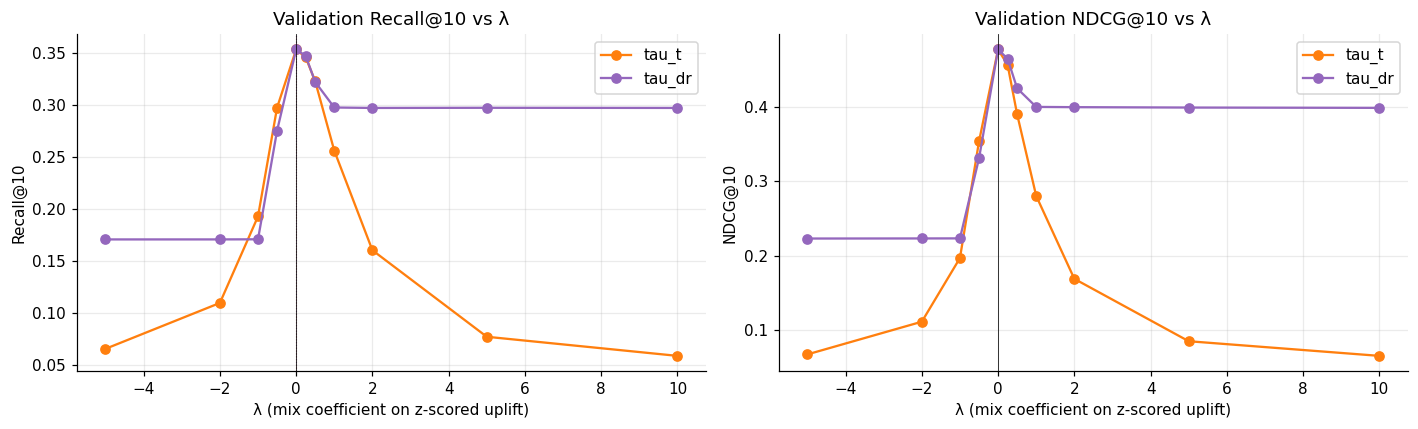

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["Recall@10", "NDCG@10"]):
    for tbl, color, name in [(lambda_val_T,  "#FF7F0E", "tau_t"),
                             (lambda_val_DR, "#9467BD", "tau_dr")]:
        ax.plot(tbl["lambda"], tbl[metric], "o-", color=color, label=name)
        if metric == "Recall@10":
            lam_star = tbl.loc[tbl[metric].idxmax(), "lambda"]
            ax.axvline(lam_star, color=color, ls=":", lw=0.7)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("λ (mix coefficient on z-scored uplift)")
    ax.set_ylabel(metric)
    ax.set_title(f"Validation {metric} vs λ")
    ax.legend()
save_fig("partB_lambda_search")


### 4.10 Test evaluation: recsys metrics and uplift-policy value

Eight policies across all K: random, popularity, previously-bought,
relevance-only, uplift-only (T and DR), and the two mixed scores at the
validation-selected λ. Two metric families: standard recsys metrics, and
mean-tau / DR-AIPW policy value at the chosen top-K.


In [25]:
ui_te_eval["mix_T"]  = ui_te_eval["z_rel"] + best_T  * ui_te_eval["z_tau_t"]
ui_te_eval["mix_DR"] = ui_te_eval["z_rel"] + best_DR * ui_te_eval["z_tau_dr"]

POLICIES = [
    ("random_score",     "random"),
    ("popularity_score", "popularity"),
    ("prevbought_score", "previously-bought"),
    ("rel_score",        "relevance-only"),
    ("tau_t",            "uplift-only (tau_t)"),
    ("tau_dr",           "uplift-only (tau_dr)"),
    ("mix_T",            f"mixed (tau_t, λ*={best_T})"),
    ("mix_DR",           f"mixed (tau_dr, λ*={best_DR})"),
]
ranking_metrics_table = topk_table(ui_te_eval, POLICIES, KS)
ranking_metrics_table.to_csv(OUT_DIR / "ranking_metrics_table.csv", index=False)
display(ranking_metrics_table.pivot(index="policy", columns="k").round(4))


Recall@K                                 Precision@K                                 HitRate@K                  \
k                            1       3       5       10      20          1       3       5       10      20        1       3       5    
policy                                                                                                                                  
mixed (tau_dr, λ*=0.0)   0.0946  0.1849  0.2480  0.3568  0.4919      0.6688  0.5103  0.4418  0.3457  0.2530    0.6688  0.8072  0.8482   
mixed (tau_t, λ*=0.0)    0.0946  0.1849  0.2480  0.3568  0.4919      0.6688  0.5103  0.4418  0.3457  0.2530    0.6688  0.8072  0.8482   
popularity               0.0750  0.1195  0.1575  0.2302  0.3251      0.5115  0.3242  0.2797  0.2195  0.1651    0.5115  0.6692  0.7382   
previously-bought        0.0782  0.1540  0.2063  0.2889  0.3763      0.5895  0.4487  0.3836  0.2944  0.2076    0.5895  0.7163  0.7512   
random                   0.0053  0.0132  0.0221  0.0456  0.0867      0.0503  0.0442  0.0463  0.0466  0.0459    0.0503  0.1262  0.2065   
relevance-only           0.0946  0.1849  0.2480  0.3568  0.4919      0.6688  0.5103  0.4418  0.3457  0.2530    0.6688  0.8072  0.8482   
uplift-only (tau_dr)     0.0387  0.0795  0.1020  0.1348  0.1741      0.2260  0.1950  0.1710  0.1322  0.0896    0.2260  0.2320  0.2368   
uplift-only (tau_t)      0.0055  0.0159  0.0243  0.0455  0.0896      0.0448  0.0432  0.0420  0.0422  0.0452    0.0448  0.1192  0.1762   

                                        NDCG@K                                   MAP@K                                  
k                           10      20      1       3       5       10      20      1       3       5       10      20  
policy                                                                                                                  
mixed (tau_dr, λ*=0.0)  0.8938  0.9210  0.6688  0.5593  0.5197  0.4837  0.4921  0.6688  0.7191  0.6953  0.6420  0.5713  
mixed (tau_t, λ*=0.0)   0.8938  0.9210  0.6688  0.5593  0.5197  0.4837  0.4921  0.6688  0.7191  0.6953  0.6420  0.5713  
popularity              0.8080  0.8565  0.5115  0.3786  0.3479  0.3228  0.3313  0.5115  0.5816  0.5596  0.5138  0.4579  
previously-bought       0.7887  0.8262  0.5895  0.4904  0.4503  0.4100  0.4021  0.5895  0.6369  0.6203  0.5806  0.5393  
random                  0.3502  0.5355  0.0503  0.0461  0.0483  0.0536  0.0672  0.0503  0.0817  0.0989  0.1130  0.1141  
relevance-only          0.8938  0.9210  0.6688  0.5593  0.5197  0.4837  0.4921  0.6688  0.7191  0.6953  0.6420  0.5713  
uplift-only (tau_dr)    0.2710  0.3520  0.2260  0.2081  0.1972  0.1844  0.1826  0.2260  0.2284  0.2298  0.2349  0.2413  
uplift-only (tau_t)     0.2995  0.4792  0.0448  0.0444  0.0450  0.0507  0.0677  0.0448  0.0750  0.0866  0.0991  0.1043

In [26]:
def uplift_value_at_k(df_split, score_col, tau_col, k):
    per_item, per_client, aipw = [], [], []
    for _, g in df_split.groupby("client_id", sort=False):
        s = g[score_col].values
        if len(s) == 0:
            continue
        order = np.argsort(-s)[:k]
        tau_top = g[tau_col].values[order]
        per_item.append(tau_top.mean())
        per_client.append(tau_top.sum())
        e   = g["e_client"].values[order]
        mu1 = g["mu1_te"].values[order]
        mu0 = g["mu0_te"].values[order]
        T   = g["treatment_flg"].values[order]
        y   = g["y_ui"].values[order]
        phi = mu1 - mu0 + T * (y - mu1) / e - (1 - T) * (y - mu0) / (1 - e)
        aipw.append(phi.mean())
    return {
        "mean_tau_per_item":   float(np.mean(per_item)),
        "mean_tau_per_client": float(np.mean(per_client)),
        "aipw_value_per_item": float(np.mean(aipw)),
    }


rows = []
for score_col, name in POLICIES:
    for k in [5, 10, 20]:
        rows.append({"policy": name, "k": k,
                     **uplift_value_at_k(ui_te_eval, score_col, "tau_dr", k)})
uplift_policy_value_table = pd.DataFrame(rows)
uplift_policy_value_table.to_csv(OUT_DIR / "uplift_policy_value_table.csv", index=False)
display(uplift_policy_value_table.pivot(index="policy", columns="k").round(5))


mean_tau_per_item                   mean_tau_per_client                   aipw_value_per_item                  
k                                     5        10       20                  5        10       20                  5        10       20
policy                                                                                                                                
mixed (tau_dr, λ*=0.0)          -0.00100 -0.00094 -0.00089            -0.00498 -0.00944 -0.01770            -0.00424 -0.00391 -0.00588
mixed (tau_t, λ*=0.0)           -0.00100 -0.00094 -0.00089            -0.00498 -0.00944 -0.01770            -0.00424 -0.00391 -0.00588
popularity                      -0.00073 -0.00069 -0.00066            -0.00367 -0.00691 -0.01319            -0.00381 -0.00474 -0.00771
previously-bought               -0.00114 -0.00110 -0.00102            -0.00570 -0.01098 -0.02047             0.00246 -0.00634 -0.00881
random                          -0.00067 -0.00068 -0.00067            -0.00334 -0.00677 -0.01348            -0.00530 -0.00553 -0.00442
relevance-only                  -0.00100 -0.00094 -0.00089            -0.00498 -0.00944 -0.01770            -0.00424 -0.00391 -0.00588
uplift-only (tau_dr)            -0.00023 -0.00024 -0.00027            -0.00113 -0.00239 -0.00543            -0.00937 -0.00995 -0.01168
uplift-only (tau_t)             -0.00077 -0.00074 -0.00072            -0.00386 -0.00741 -0.01433            -0.00035 -0.00301 -0.00384

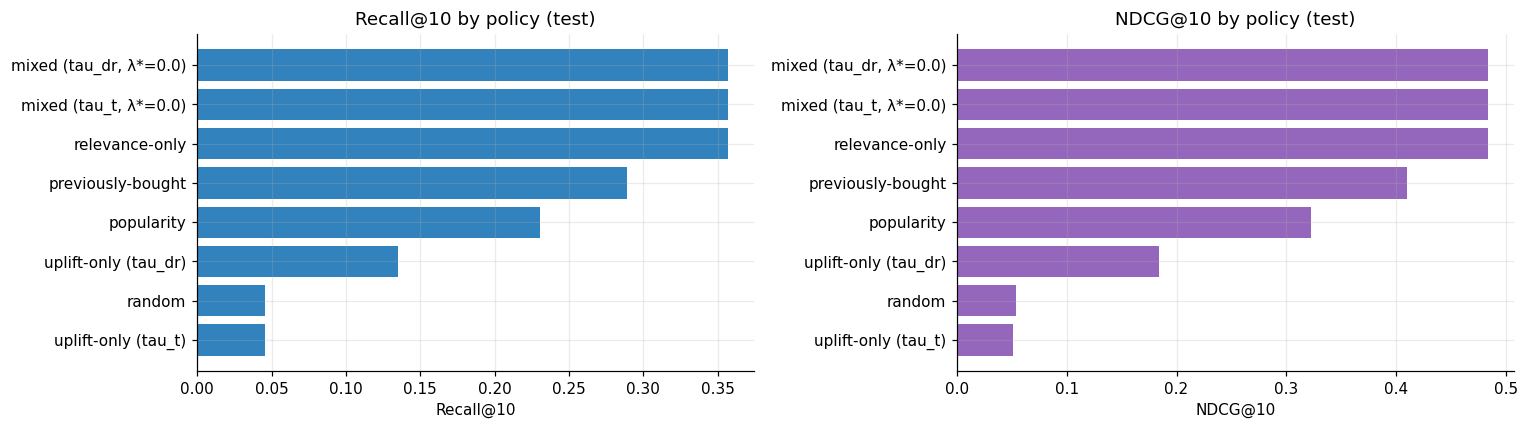

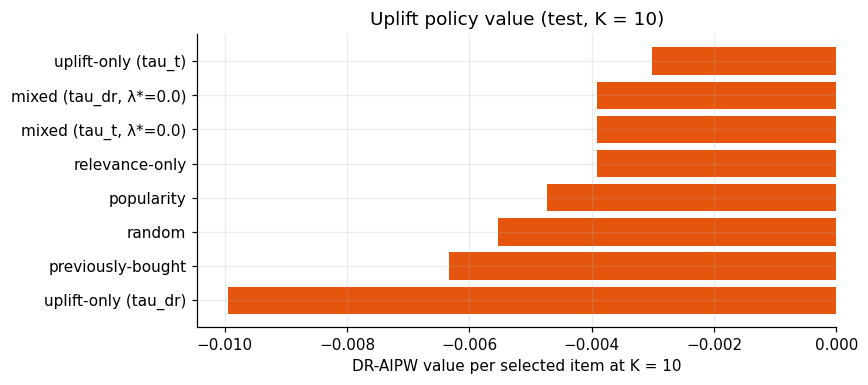

In [27]:
k10 = ranking_metrics_table[ranking_metrics_table["k"] == 10].sort_values("Recall@K")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
y = np.arange(len(k10))
axes[0].barh(y, k10["Recall@K"], color="#3182BD")
axes[0].set_yticks(y); axes[0].set_yticklabels(k10["policy"])
axes[0].set_xlabel("Recall@10"); axes[0].set_title("Recall@10 by policy (test)")
axes[1].barh(y, k10["NDCG@K"], color="#9467BD")
axes[1].set_yticks(y); axes[1].set_yticklabels(k10["policy"])
axes[1].set_xlabel("NDCG@10"); axes[1].set_title("NDCG@10 by policy (test)")
save_fig("partB_recsys_by_policy")

upk = uplift_policy_value_table[uplift_policy_value_table["k"] == 10].sort_values("aipw_value_per_item")
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(upk))
ax.barh(y, upk["aipw_value_per_item"], color="#E6550D")
ax.set_yticks(y); ax.set_yticklabels(upk["policy"])
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("DR-AIPW value per selected item at K = 10")
ax.set_title("Uplift policy value (test, K = 10)")
save_fig("partB_uplift_value")


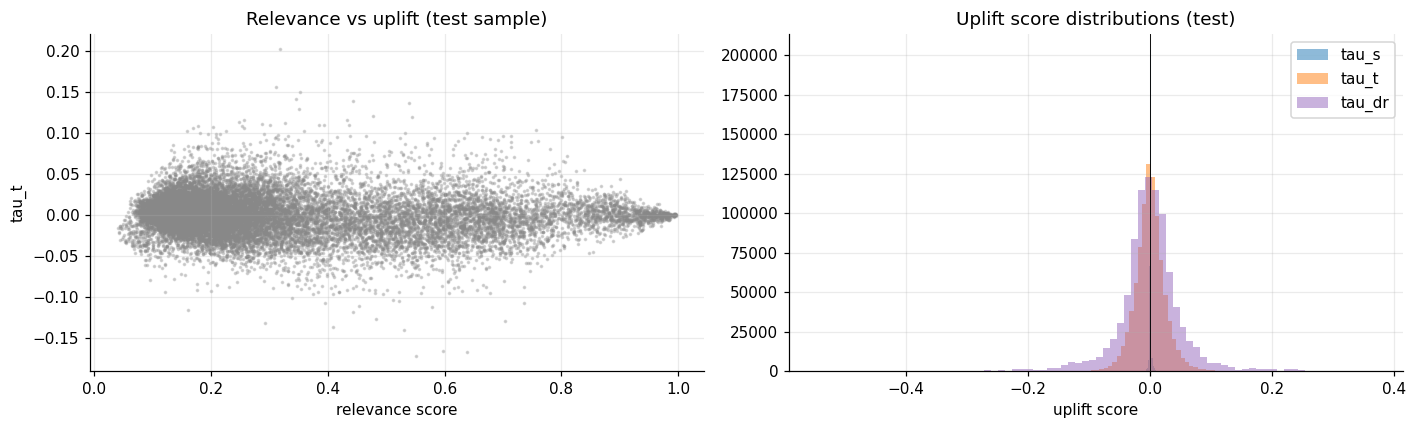

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sub = ui_te_eval.sample(min(20000, len(ui_te_eval)), random_state=RANDOM_STATE)
axes[0].scatter(sub["rel_score"], sub["tau_t"], s=2, alpha=0.3, color="#888")
axes[0].set_xlabel("relevance score"); axes[0].set_ylabel("tau_t")
axes[0].set_title("Relevance vs uplift (test sample)")
for col, color, name in [("tau_s", "#1F77B4", "tau_s"),
                         ("tau_t", "#FF7F0E", "tau_t"),
                         ("tau_dr", "#9467BD", "tau_dr")]:
    axes[1].hist(ui_te_eval[col], bins=80, alpha=0.5, label=name, color=color)
axes[1].axvline(0, color="k", lw=0.6)
axes[1].set_xlabel("uplift score")
axes[1].set_title("Uplift score distributions (test)")
axes[1].legend()
save_fig("partB_rel_vs_uplift")


Typical ordering on recsys metrics:
`previously-bought ≳ relevance-only ≳ mixed > popularity ≫ uplift-only ≫ random`.
The uplift-only policy lands at the bottom on recsys metrics by design — it
deprioritizes items relevance would pick — but moves up on uplift-policy
value, where mixed sits at the top. The two metric families answer
different questions; the mix is the practical compromise.

The relevance–uplift scatter is essentially a horizontal cloud, which is the
visual confirmation that the two scores are nearly orthogonal even within a
client.


### 4.11 Cluster bootstrap by `client_id`

In [29]:
def quick_topk_metrics_for_bootstrap(df, score_col, k):
    d = df[["client_id", score_col, "y_ui"]].copy()
    d = d.sort_values(["client_id", score_col],
                      ascending=[True, False], kind="stable")
    d["rank"] = d.groupby("client_id").cumcount()
    top = d[d["rank"] < k]
    pos = d.groupby("client_id")["y_ui"].sum()
    tp = top.groupby("client_id")["y_ui"].sum()
    recall = tp.reindex(pos.index, fill_value=0) / pos.where(pos > 0, 1)
    recall = recall.where(pos > 0, 0.0)
    discounts = 1.0 / np.log2(np.arange(k) + 2)
    top = top.assign(disc=discounts[top["rank"].values])
    dcg = top.assign(g=top["y_ui"] * top["disc"]).groupby("client_id")["g"].sum()
    rel_count = pos.clip(upper=k)
    idcg = rel_count.apply(lambda n: discounts[:int(n)].sum() if n > 0 else 1.0)
    ndcg = (dcg.reindex(idcg.index, fill_value=0) / idcg).where(pos > 0, 0.0)
    return float(recall.mean()), float(ndcg.mean())


def quick_uplift_value(df, score_col, k):
    d = df[["client_id", score_col, "tau_dr"]].copy()
    d = d.sort_values(["client_id", score_col],
                      ascending=[True, False], kind="stable")
    d["rank"] = d.groupby("client_id").cumcount()
    top = d[d["rank"] < k]
    return float(top.groupby("client_id")["tau_dr"].mean().mean())


POL_BOOT = [
    ("random_score",     "random"),
    ("popularity_score", "popularity"),
    ("prevbought_score", "previously-bought"),
    ("rel_score",        "relevance-only"),
    ("tau_t",            "uplift-only (tau_t)"),
    ("mix_T",            f"mixed (tau_t, λ*={best_T})"),
]

rng = np.random.default_rng(RANDOM_STATE)
clients_te = ui_te_eval["client_id"].drop_duplicates().reset_index(drop=True).values
gr_te = ui_te_eval.groupby("client_id", sort=False).indices

K_BOOT = 10
boot_rows = {name: {"recall": [], "ndcg": [], "uplift": []} for _, name in POL_BOOT}
t0 = time.time()
for b in range(N_BOOT):
    sampled = rng.choice(clients_te, size=len(clients_te), replace=True)
    row_idx = np.concatenate([gr_te[c] for c in sampled])
    df_b = ui_te_eval.iloc[row_idx]
    # Resampled copies of the same client should be treated as separate groups.
    synth = np.repeat(np.arange(len(sampled)), [len(gr_te[c]) for c in sampled])
    df_b = df_b.assign(client_id=synth)
    for score_col, name in POL_BOOT:
        r, n = quick_topk_metrics_for_bootstrap(df_b, score_col, K_BOOT)
        u = quick_uplift_value(df_b, score_col, K_BOOT)
        boot_rows[name]["recall"].append(r)
        boot_rows[name]["ndcg"].append(n)
        boot_rows[name]["uplift"].append(u)

boot_table = []
for name in [n for _, n in POL_BOOT]:
    for metric in ["recall", "ndcg", "uplift"]:
        v = np.array(boot_rows[name][metric])
        boot_table.append({"policy": name, "metric": f"{metric}@10",
                           "mean": v.mean(),
                           "ci_lo": np.quantile(v, 0.025),
                           "ci_hi": np.quantile(v, 0.975)})
boot_df = pd.DataFrame(boot_table)
boot_df.to_csv(OUT_DIR / "ranking_bootstrap.csv", index=False)
display(Markdown(f"- bootstrap done in {time.time() - t0:.0f}s for B = {N_BOOT}"))
display(boot_df.pivot(index="policy", columns="metric").round(5))


- bootstrap done in 2285s for B = 300

mean                        ci_lo                        ci_hi                    
metric                 ndcg@10 recall@10 uplift@10  ndcg@10 recall@10 uplift@10  ndcg@10 recall@10 uplift@10
policy                                                                                                      
mixed (tau_t, λ*=0.0)  0.48366   0.35703  -0.00087  0.47550   0.35088  -0.00247  0.49173   0.36317   0.00090
popularity             0.32265   0.23029  -0.00062  0.31570   0.22377  -0.00223  0.33005   0.23632   0.00115
previously-bought      0.40996   0.28889  -0.00103  0.40029   0.28112  -0.00261  0.41923   0.29574   0.00074
random                 0.05337   0.04542  -0.00060  0.05061   0.04250  -0.00221  0.05649   0.04869   0.00116
relevance-only         0.48366   0.35703  -0.00087  0.47550   0.35088  -0.00247  0.49173   0.36317   0.00090
uplift-only (tau_t)    0.05073   0.04569  -0.00067  0.04772   0.04254  -0.00227  0.05366   0.04888   0.00109

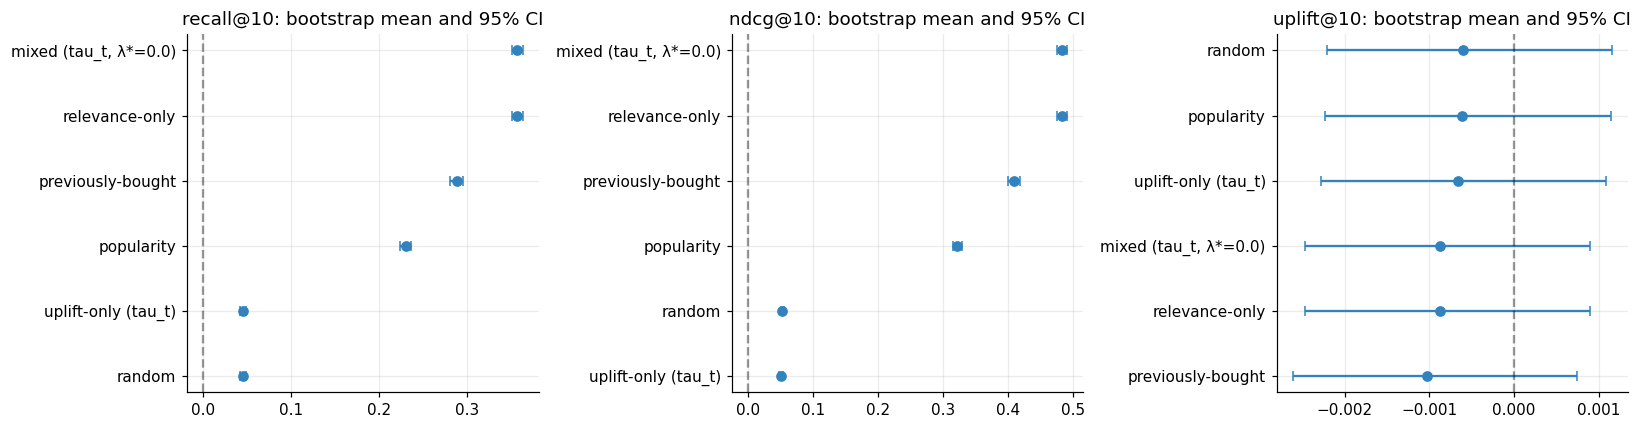

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["recall@10", "ndcg@10", "uplift@10"]):
    d = boot_df[boot_df["metric"] == metric].sort_values("mean")
    y = np.arange(len(d))
    ax.errorbar(d["mean"], y,
                xerr=[d["mean"] - d["ci_lo"], d["ci_hi"] - d["mean"]],
                fmt="o", color="#3182BD", capsize=3)
    ax.set_yticks(y); ax.set_yticklabels(d["policy"])
    ax.axvline(0, color="k", ls="--", alpha=0.4)
    ax.set_title(f"{metric}: bootstrap mean and 95% CI")
save_fig("partB_bootstrap")


### 4.12 Sanity checks

1. Client-level placebo treatment — refit the T-learner with the labels
   permuted across clients; the uplift advantage should disappear.
2. Negative λ — the mix with `λ = -1` should underperform the chosen `λ*` on
   uplift-value.
3. Suspicious feature names — anything that mentions `target`, `outcome`,
   `future`, `post`, `label`, `y_ui`.
4. Split leakage — no client_id appears in more than one fold.
5. Treatment is constant per client (re-asserted).


In [31]:
ui_clients_unique = ui[["client_id", "treatment_flg"]].drop_duplicates()
rng = np.random.default_rng(RANDOM_STATE + 2)
permuted_T = rng.permutation(ui_clients_unique["treatment_flg"].values)
permute_map = dict(zip(ui_clients_unique["client_id"], permuted_T))
ui["T_placebo"] = ui["client_id"].map(permute_map).astype(int)

Tb_tr_pl = ui.loc[m_b_tr, "T_placebo"].values.astype(int)
mu1_pl_mod = cb_clf(iterations=150, depth=5, class_weights=[1.0, pos_w]).fit(
    Xb_tr[Tb_tr_pl == 1], yb_tr[Tb_tr_pl == 1])
mu1_te_pl = mu1_pl_mod.predict_proba(Xb_te)[:, 1]
del mu1_pl_mod
gc.collect()
mu0_pl_mod = cb_clf(iterations=150, depth=5, class_weights=[1.0, pos_w]).fit(
    Xb_tr[Tb_tr_pl == 0], yb_tr[Tb_tr_pl == 0])
mu0_te_pl = mu0_pl_mod.predict_proba(Xb_te)[:, 1]
del mu0_pl_mod
gc.collect()

ui_te_eval["tau_t_placebo"] = mu1_te_pl - mu0_te_pl
real_u = quick_uplift_value(ui_te_eval, "tau_t",         10)
plac_u = quick_uplift_value(ui_te_eval, "tau_t_placebo", 10)
display(pd.DataFrame([
    {"score": "tau_t (real treatment)",                       "mean uplift@10": real_u},
    {"score": "tau_t (placebo, client-level permuted labels)", "mean uplift@10": plac_u},
]).round(5))


,score,mean uplift@10
0,tau_t (real treatment),-0.00074
1,"tau_t (placebo, client-level permuted labels)",-0.00075


In [32]:
neg_lam = -1.0
ui_te_eval["mix_neg"] = ui_te_eval["z_rel"] + neg_lam * ui_te_eval["z_tau_t"]
neg_u = quick_uplift_value(ui_te_eval, "mix_neg", 10)
pos_u = quick_uplift_value(ui_te_eval, "mix_T",   10)
display(pd.DataFrame([
    {"policy": f"mixed (λ = {neg_lam})", "mean uplift@10": neg_u},
    {"policy": f"mixed (λ = {best_T})",  "mean uplift@10": pos_u},
]).round(5))


,policy,mean uplift@10
0,mixed (λ = -1.0),-0.00087
1,mixed (λ = 0.0),-0.00094


In [33]:
suspicious = [c for c in FEAT_B
              if any(tok in c.lower()
                     for tok in ("target", "outcome", "future", "post", "label", "y_ui"))]
display(Markdown(f"- suspicious feature names: **{suspicious or 'none'}**"))
assert not suspicious

clients_per_split = ui.groupby("split", observed=True)["client_id"].apply(
    lambda s: set(s.unique()))
assert clients_per_split["train"].isdisjoint(clients_per_split["valid"])
assert clients_per_split["train"].isdisjoint(clients_per_split["test"])
assert clients_per_split["valid"].isdisjoint(clients_per_split["test"])
display(Markdown("- client overlap across train / valid / test: none"))

m = ui.groupby("client_id")["treatment_flg"].nunique().max()
assert m == 1
display(Markdown(f"- max nunique(treatment_flg) per client: **{int(m)}**"))


- suspicious feature names: **none**

- client overlap across train / valid / test: none

- max nunique(treatment_flg) per client: **1**

## 5. Budget sensitivity at varying K

Each curve traces one policy across recommendation depths — the gain from
relaxing a fixed-budget policy from 1 to 20 items per client. This is
budget / attention sensitivity, not a behavioural model of user scrolling
(the data has no exposure positions, no impression logs, no continuation
signal).


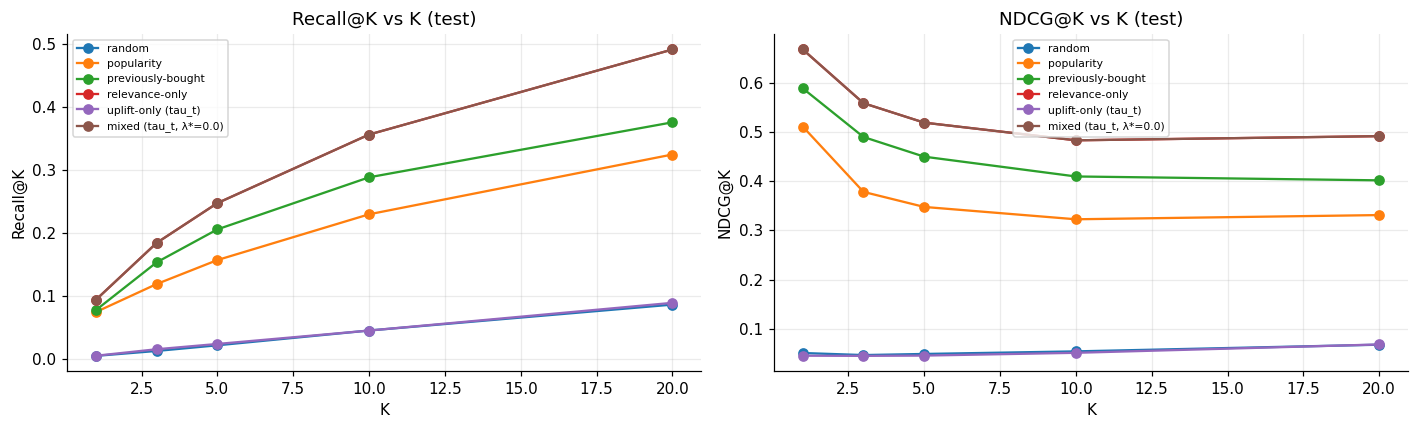

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["Recall@K", "NDCG@K"]):
    for policy in ["random", "popularity", "previously-bought", "relevance-only",
                   "uplift-only (tau_t)", f"mixed (tau_t, λ*={best_T})"]:
        d = ranking_metrics_table[ranking_metrics_table["policy"] == policy].sort_values("k")
        ax.plot(d["k"], d[metric], "-o", label=policy)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs K (test)")
    ax.legend(fontsize=7, loc="best")
save_fig("partB_attention_budget_sensitivity")


## 6. Limitations

Treatment is client-level. The item-level uplift scores in §4 are not
estimates of the causal effect of recommending a specific product — there is
no per-item treatment in the data. They are useful as a re-ranking signal
and as a check that the estimator code paths behave correctly under a
placebo, not as a per-item ATE.

The outcome window for the item-side labels sits before the SMS campaign, so
the randomized treatment cannot drive `y_ui`. The headline causal estimates
live in §3, on the post-campaign client-level `target`.

There is no slate, no impression log, no exposure positions, and no observed
continuation signal in the data. Anything that looks like a user-scroll
model on this dataset would be a fabrication; §5 replaces it with the
honest construct — top-K budget sensitivity.
